数据集形状: (20640, 8)
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
目标变量范围: 0.15 - 5.00
线性回归:训练误差=0.5178, 验证误差=0.5193, 差距=0.0015
岭回归 (alpha=1):训练误差=0.5178, 验证误差=0.5193, 差距=0.0015
决策树 (max_depth=3):训练误差=0.6159, 验证误差=0.6332, 差距=0.0174
决策树 (max_depth=10):训练误差=0.2019, 验证误差=0.4123, 差距=0.2104
随机森林:训练误差=0.0369, 验证误差=0.2617, 差距=0.2248


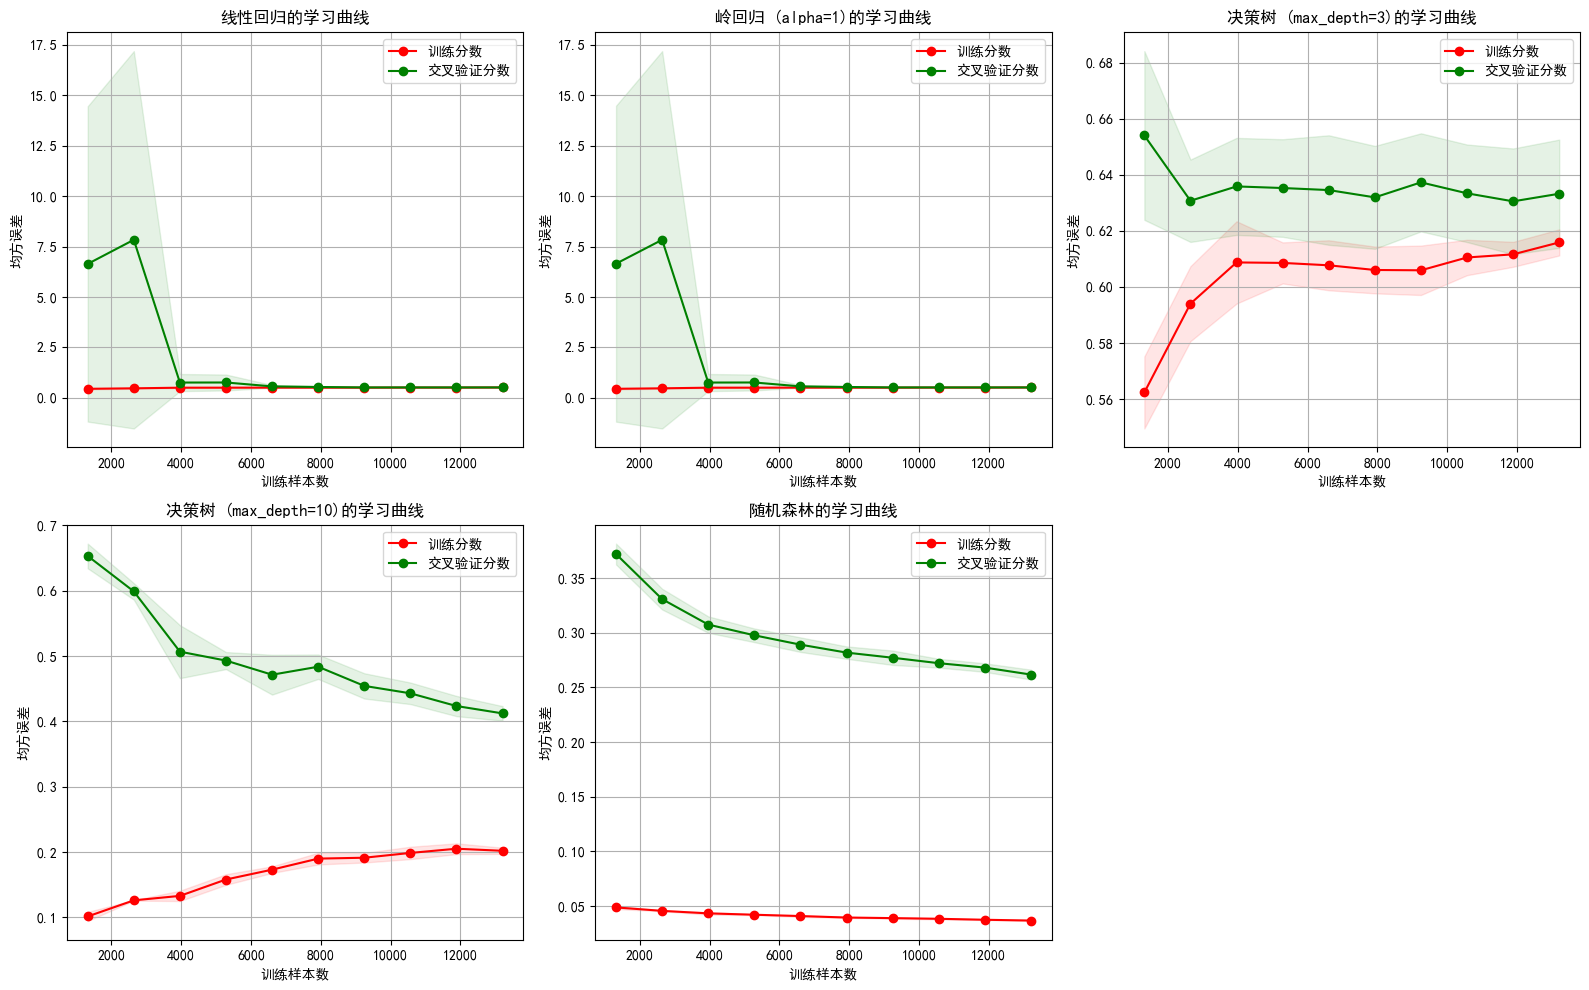

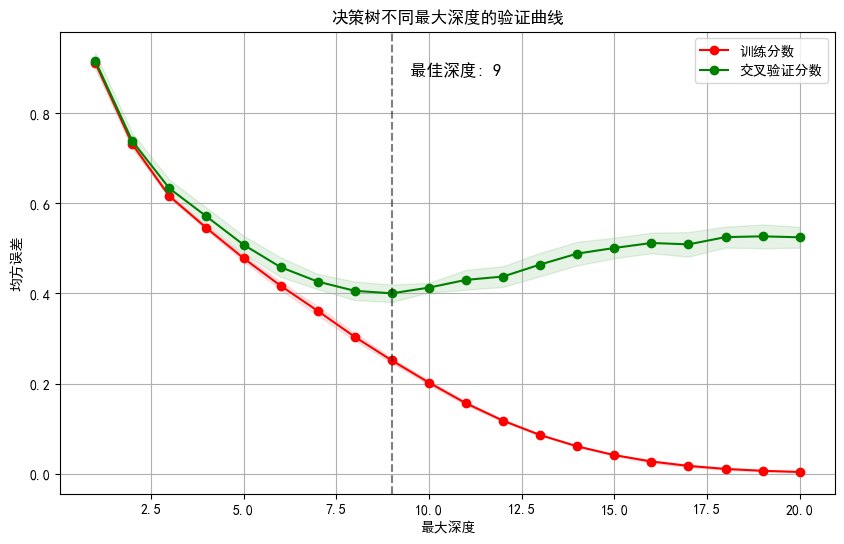

最佳最大深度: 9


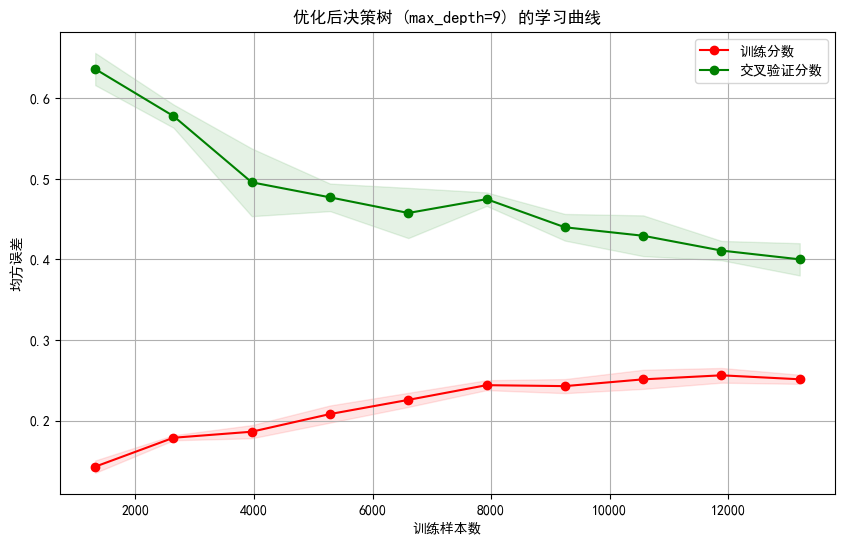

优化后模型在测试集上的均方误差: 0.4151


In [1]:
# %load 5-6.py
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

# ÉèÖÃÖÐÎÄ×ÖÌåºÍ¸ººÅÏÔÊ¾
#plt.rcParams['font.sans-serif'] = ['SimHei']
#plt.rcParams['axes.unicode_minus'] = False

# ¼ÓÔØ¼ÓÖÝ×¡·¿Êý¾Ý¼¯
california = fetch_california_housing()
X, y = california.data, california.target

# Êý¾Ý»ù±¾ÐÅÏ¢
print(f"数据集形状: {X.shape}")
print(f"特征名称: {california.feature_names}")
print(f"目标变量范围: {y.min():.2f} - {y.max():.2f}")

# »®·ÖÑµÁ·¼¯ºÍ²âÊÔ¼¯
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ´´½¨²»Í¬¸´ÔÓ¶ÈµÄÄ£ÐÍ
models = {
    "线性回归": LinearRegression(),
    "岭回归 (alpha=1)": Ridge(alpha=1),
    "决策树 (max_depth=3)": DecisionTreeRegressor(max_depth=3, random_state=42),
    "决策树 (max_depth=10)": DecisionTreeRegressor(max_depth=10, random_state=42),
    "随机森林": RandomForestRegressor(n_estimators=100, random_state=42)
}

# ÎªÃ¿¸öÄ£ÐÍ´´½¨¹ÜµÀ£¨°üº¬±ê×¼»¯£©
pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

# ¼ÆËãÑ§Ï°ÇúÏß
def plot_learning_curves(models, X, y):
    plt.figure(figsize=(16, 10))
    
    for i, (name, pipeline) in enumerate(models.items()):
        # ¼ÆËãÑ§Ï°ÇúÏß
        train_sizes, train_scores, test_scores = learning_curve(
            pipeline, X, y, cv=5, 
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='neg_mean_squared_error',
            n_jobs=-1
        )
        
        # ¼ÆËã¾ùÖµºÍ±ê×¼²î
        train_scores_mean = -np.mean(train_scores, axis=1)
        train_scores_std = np.std(train_scores, axis=1)
        test_scores_mean = -np.mean(test_scores, axis=1)
        test_scores_std = np.std(test_scores, axis=1)
        
        # »æÖÆÑ§Ï°ÇúÏß
        plt.subplot(2, 3, i+1)
        plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                         train_scores_mean + train_scores_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                         test_scores_mean + test_scores_std, alpha=0.1, color="g")
        plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="训练分数")
        plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="交叉验证分数")
        
        plt.xlabel("训练样本数")
        plt.ylabel("均方误差")
        plt.title(f"{name}的学习曲线")
        plt.legend(loc="best")
        plt.grid(True)
        
        # ´òÓ¡×îÖÕÐÔÄÜ
        final_train_score = train_scores_mean[-1]
        final_test_score = test_scores_mean[-1]
        print(f"{name}:训练误差={final_train_score:.4f}, 验证误差={final_test_score:.4f}, 差距={final_test_score-final_train_score:.4f}")
    
    plt.tight_layout()
    plt.show()

# »æÖÆËùÓÐÄ£ÐÍµÄÑ§Ï°ÇúÏß
plot_learning_curves(pipelines, X_train, y_train)

# Ñ¡ÔñÒ»¸öÄ£ÐÍ½øÐÐÉîÈë·ÖÎö - ¾ö²ßÊ÷ (max_depth=10)
model_name = "决策树 (max_depth=10)"
pipeline = pipelines[model_name]

# ·ÖÎö²»Í¬max_depth¶ÔÄ£ÐÍµÄÓ°Ïì
max_depths = np.arange(1, 21)

# ¼ÆËãÑéÖ¤ÇúÏß
train_scores, test_scores = validation_curve(
    pipeline.named_steps['model'], 
    StandardScaler().fit_transform(X_train), y_train,
    param_name="max_depth", 
    param_range=max_depths,
    cv=5, 
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# ¼ÆËã¾ùÖµºÍ±ê×¼²î
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# »æÖÆÑéÖ¤ÇúÏß
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores_mean, 'o-', color="r", label="训练分数")
plt.plot(max_depths, test_scores_mean, 'o-', color="g", label="交叉验证分数")
plt.fill_between(max_depths, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(max_depths, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")

plt.xlabel("最大深度")
plt.ylabel("均方误差")
plt.title("决策树不同最大深度的验证曲线")
plt.legend(loc="best")
plt.grid(True)

# ±ê¼Ç×î¼Ñ²ÎÊý
best_depth = max_depths[np.argmin(test_scores_mean)]
plt.axvline(x=best_depth, linestyle='--', color='k', alpha=0.5)
plt.text(best_depth+0.5, plt.ylim()[1]*0.9, f'最佳深度: {best_depth}', fontsize=12)

plt.show()

print(f"最佳最大深度: {best_depth}")

# Ê¹ÓÃ×î¼Ñ²ÎÊýÖØÐÂÑµÁ·Ä£ÐÍ
best_model = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

# ¼ÆËãÐÂÄ£ÐÍµÄÑ§Ï°ÇúÏß
train_sizes, train_scores, test_scores = learning_curve(
    best_pipeline, X_train, y_train, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# ¼ÆËã¾ùÖµºÍ±ê×¼²î
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# »æÖÆÓÅ»¯ºóµÄÑ§Ï°ÇúÏß
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="训练分数")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="交叉验证分数")

plt.xlabel("训练样本数")
plt.ylabel("均方误差")
plt.title(f"优化后决策树 (max_depth={best_depth}) 的学习曲线")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# ÆÀ¹À×îÖÕÄ£ÐÍÔÚ²âÊÔ¼¯ÉÏµÄÐÔÄÜ
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)

print(f"优化后模型在测试集上的均方误差: {test_mse:.4f}")